# MNIST

Bu fəsildə MNIST datasetindən istifadə edəcəyik. MNIST 70,000 kiçik şəkildən ibarət bir dəstdir; bu şəkillər ABŞ Sayım Bürosunun işçiləri və orta məktəb şagirdləri tərəfindən əl ilə yazılmış rəqəmləri göstərir. Hər bir şəkil, nümayiş etdirdiyi rəqəm ilə etiketlənmişdir. Bu dataset o qədər geniş tədqiq olunub ki, onu tez-tez “Machine Learning-in Hello World-u” adlandırırlar: insanlar yeni təsnifat alqoritmi yaratdıqda, onun MNIST üzərində necə işləyəcəyini görmək istəyirlər. Hər kəs Machine Learning öyrənərkən bir vaxt sonra MNIST üzərində işləyir.

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, parser='auto')

X, y = mnist.data ,  mnist.target

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [2]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

Datasetdə 70,000 şəkil var və hər bir şəkil 784 xüsusiyyətə malikdir. Bunun səbəbi, hər bir şəkilin 28×28 piksel ölçüsündə olmasıdır; hər bir xüsusiyyət sadəcə bir pikselin intensivliyini göstərir, 0 (ağ) ilə 255 (qara) arasında.

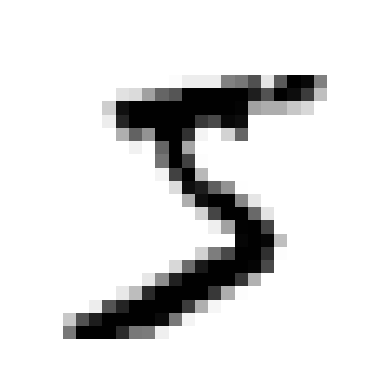

In [3]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

# 1. some_digit seçimi: X[0] kimi deyil, X.iloc[0] olmalıdır
some_digit = X.iloc[0]  # DataFrame-dən düzgün sətir seçmək

# 2. Əvvəlcə NumPy array-ə çevirmək lazımdır (Pandas Series-dən)
some_digit_image = some_digit.values.reshape(28, 28)

plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation="nearest")
plt.axis("off")
plt.show()


Amma diqqət yetirin! Dataseti yaxından incələmədən əvvəl mütləq test dəsti yaratmalısınız. MNIST datasetində artıq təlim və test dəstləri mövcuddur:

Təlim dəsti:  - ilk 60,000 şəkil

Test dəsti:    - son 10,000 şəkil 

In [4]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]


In [5]:
type(X_train)

pandas.core.frame.DataFrame

In [6]:
type(y_train)

pandas.core.series.Series

Training dataseti  qarisdirmaq vacibdir , cunki  cross validation  fold larinin  benzer olmasini  temin edir. Telim numunelerinin  sirasindan  asili olan alqortimlerde eyni  tip  numuneler ardicil  geldikde zeif isleye biler.


In [ ]:
import numpy as np

shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train.iloc[shuffle_index], y_train.iloc[shuffle_index]

X_train = X_train.values  #  X_train  dataframe deyene , array  yaratdiq
y_train = y_train.astype(int)  # str olduguna gore deyisildi  
y_test = y_test.astype(int)   # str olduguna gore deyisildi

# Training a Binary Classifier


İndi problemi sadələşdirək və yalnız bir rəqəmi tanımağa çalışaq — məsələn, 5 rəqəmini. Bu “5-detektor” iki sinfi ayırd edə bilən bir ikili klassifikator (binary classifier) olacaq:

5

5 olmayan bütün digər rəqəmlər

In [ ]:
y_train_5 = (y_train == 5)  # True for all 5s, False for all other digits.
y_test_5  = (y_test == 5)
print(y_test_5  , '\n ',y_train_5)

60000    False
60001    False
60002    False
60003    False
60004    False
         ...  
69995    False
69996    False
69997    False
69998     True
69999    False
Name: class, Length: 10000, dtype: bool 
  38984    False
15288    False
27397    False
43723    False
11083    False
         ...  
46777    False
5363      True
42079    False
39959    False
53720    False
Name: class, Length: 60000, dtype: bool


In [9]:
type(X_train)


numpy.ndarray

Stoxastik Gradient Descent - klassifikatoru  secek cunki  cox boyuk  datasetlerle semerli isleye bilir ve training numunlerin bir birinden asili olmadan tek-tek  emal  edir . Buna gore online learning-de cox ist edilir .  

In [10]:
from  sklearn.linear_model  import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train , y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [11]:
sgd_clf.predict([some_digit])

array([ True])

# Performance Measures


klassifikatorun qiymetlendirlmesi  reqressordan daha cetindir.MOdelin keyfiyyetinin olculmesinde tek  metrika kifayet etmir.  Bir nece perforamns gostericisi  paralel istifade edilir.

## Measuring Accuracy Using Cross-Validation


Bir modelu  qiymetlendirmeyin en etibarli  yolu  cross_validatio  metodudur. Bu yanasma model-i  bir nece ferqli bolunme uzerinden  train-test  bolunmesi le sinaqdan kecirmeye imkan verir.

Bezi hallarda prossi ozun idare etmek isteyirsen. buna gore Stratified Fold ist edilir .

Esas ustunluyu  her fold -da sinif nisbetleri  qorunur .Imbalanced dataset de muhimdir.

In [12]:
from  sklearn.model_selection  import StratifiedKFold
from  sklearn.base  import  clone 

skfolds =StratifiedKFold(n_splits=3)   #  dataset 3 hisseye bolunur 

for train_index ,test_index in  skfolds.split(X_train,y_train_5):
    clone_clf =clone(sgd_clf)  #  modelin bir nusxesi  yaardalir 
    # 1 FOLD
    X_train_folds = X_train  [train_index]
    y_train_folds = y_train_5[train_index]
    # 2 FOLD
    X_test_fold   = X_train  [test_index]
    y_test_fold   = y_train_5[test_index]
    # 1 FOLD UZERINDE TEST
    clone_clf.fit(X_train_folds,  y_train_folds)
    
    y_pred = clone_clf.predict(X_test_fold)
    
    #  ACCURACY  CIXARILIR
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct /  len(y_pred))

0.8759
0.8843
0.89035


1) Cross validation ile dataset-i  k fold-a bolur ,
2) her defe modeli  yeniden oyredir. 
3) Her fold ucun  accuracy  qaytarir.

In [13]:
from  sklearn.model_selection import  cross_val_score
cross_val_score(sgd_clf,
                X_train,
                y_train_5,
                cv=3,
                scoring='accuracy')

array([0.96285, 0.9658 , 0.92105])

95%    accuracy  

Bu  ikinci  kalssfikatordur .Bu  model  her bir sekli  avtomatik 5 deyil kimi tesnif edir.

In [14]:
from  sklearn.base import  BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self,X,y=None):
        pass
    def predict(self,X):
        return  np.zeros((len(X),1),dtype=bool)


In [15]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf,
                X_train,
                y_train_5,
                cv=3 ,
                scoring='accuracy')

array([0.90855, 0.9067 , 0.9137 ])

90% yuxari accuracy  


Dataset -de 5 reqemi  yalniz 10% dir . 5-deyil  desez 90% hallarda duz olacaq.

!! __yuksek accuracy  hemise yaxsi  model demek  deyil__

## Confusion Matrix

Performansi qiymetlendirmeyin  en etibarli  yolu  confusion  matrix=e baxmaqdir.
+ Esas ideyasi : Her bir real  sinfi nece defe hansi sinfi kimi  proqnozlasdirildigini  sayiriq.

meselen  model 5 - i  3 kimi  taniyirsa ,matisde 5ci setir 3cu sutunda goruruk.

cross_val_predict  --  temiz  proqnozlara ehtiyac var .

In [23]:
from  sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf,
                                 X_train,
                                 y_train_5,
                                 cv=3)

In [24]:
from  sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5 , y_train_pred)

array([[52517,  2062],
       [  944,  4477]])

+ 1-ci setir  real 0 olan  sekiller, 52517 defe 0 kimi duzgun taninib ,6371 defe 1 kimi sehv taniyib ve.s , 2,3,4/... . 
+ 2-ci setir real 1 -i  4477-defe duz tapib.




In [19]:
# confusion_matrix(y_train_5,y_train_perfect_predictions)

In [ ]:
from sklearn.metrics import precision_score, recall_score
# model sekil-5 dedikde 69% dogrudur
print(precision_score(y_train_5, y_train_pred)) 
# heqiqi 5 lerin yalniz 82% tapa bilir
print(recall_score(y_train_5, y_train_pred))

0.6846612631900902
0.8258623870134661


Harmonik  orta adi orta ile muqayisede kicik  deyerleri daah sert ceza verir.

Model o zaman yuksek f1 netice alir ki  precison ve recall yuksek olsun 

In [30]:
from  sklearn.metrics import  f1_score
f1_score(y_train_5 , y_train_pred)

0.7486622073578595

Bezi hallarda yuksek  precison lazim olur , bezi hallarda recall lazim olur.

# Precision/Recall Tradeoff


sgdclassifier qerar verende her bir numune ucun  bir score hesablayir. Bu  skor decision  functiondan gelir.

Threshold   boyuk olarsa  musbet sinfe aid edilir ,eks halda menfi.Yeni modeli threshold idare edir.

Bu balans qaçılmazdır:

Precision ↑ → Recall ↓

Recall ↑ → Precision ↓

In [35]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([3257.98724962])

In [34]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [29]:
threshold = 200000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [ ]:
y_scores = cross_val_predict(sgd_clf,
                              X_train,
                                y_train_5, 
                                cv=3,
                                method="decision_function")
y_scores
# decision_function - real eded qaytarir, true/false yox.
# 90% halda model 5 deyil , cunki  menfi skorlar cixdi

array([-16906.71796662, -33075.14293356, -10825.60521297, ...,
       -10965.97331361, -16943.25107107, -15194.17245836], shape=(60000,))

[0.09035    0.09035151 0.09035301 ... 1.         1.         1.        ]
[1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 3.68935621e-04
 1.84467810e-04 0.00000000e+00]
[-129158.15553074 -127433.99497393 -126385.95231684 ...   25437.00375608
   29660.6897776    31642.99193541]


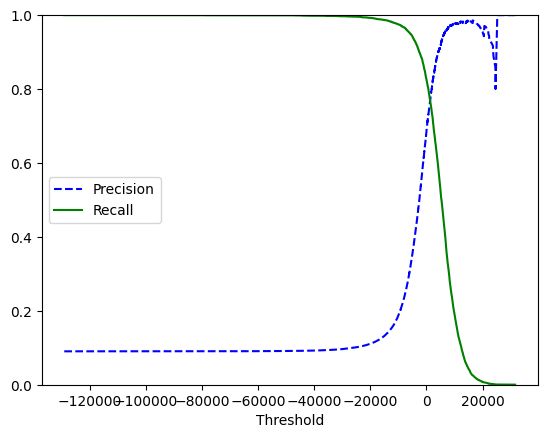

In [ ]:
from sklearn.metrics import precision_recall_curve

# Butun mumkun threshold uzeridne den recall  ve precision hesablamaq
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
print(precisions)
print(recalls)
print(thresholds)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    
    plt.xlabel("Threshold")
    plt.legend(loc="center left")
    plt.ylim([0, 1])

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [ ]:
# threshold secimi  precision  ve recall arasi trade off -a baglidir.
# Məsələn, precision 90%-ə çatmaq istəyirsənsə, threshold-u yüksək seçmək lazımdır.

In [ ]:
y_train_pred_90 = (y_scores > 70000)
from sklearn.metrics import precision_score, recall_score

print(precision_score(y_train_5, y_train_pred_90))
print(recall_score(y_train_5, y_train_pred_90))

0.0
0.0


c:\Users\USER\envs\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# ROC Curve (Receiver Operating Characteristic)

ROC curve binary klassifikasiya üçün çox istifadə olunan vizual alətdir.

Precision/Recall curve ilə oxşardır, amma ROC:

+ x-oxu → False Positive Rate (FPR)

+ y-oxu → True Positive Rate (TPR, eyni zamanda recall)

Real musbt numnelrin nece faizi dogru tapilib:
+ tpr(recall) = tp / tp + fn      

Real menfi  numnelarin  nece faizi  sehven  musbet tensif edilib
+ fpr         = fp / fp + tn


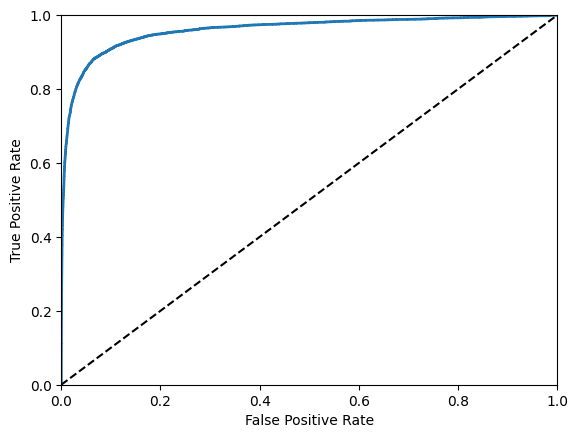

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores) # her treshold ucun  hesablanir

def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')   # tesadufi  klassifkator xetti
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
plot_roc_curve(fpr, tpr)
plt.show()


ROC curve nə qədər bu xəttin üstündədirsə → model o qədər yaxşıdır

+ Threshold yuxari -  yuksek tpr(recall)  , Yuksek FPR
+ Threshold asagi  -  asagi  tpr(recall)  , Asagi  FPR

# Area Under the Curve (AUC)

Perfect classifier → ROC AUC = 1

Random classifier → ROC AUC = 0.5

In [ ]:

from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores) 
# 96 model cox yaxsidir

0.9598347409874257

# ROC ve Precision-Recall curve 

ROC ve PR cox oxsardir .amma istofade hallari var :
1) PR ist et :Pozitiv sinif nadirdirse ,meselen 5 datasetde 10% dir. 
2) PR ist et : False pozitiv daha vacibdirse 
3) ROC ist et: Diger hallar


# RandomForestClassifier ilə ROC və AUC müqayisəsi

- SGDClassifier-də decision_function() istifadə edirdik → qərar skoru verirdi
- Random Forest isə probabilistik modeldir → predict_proba() istifadə olunur

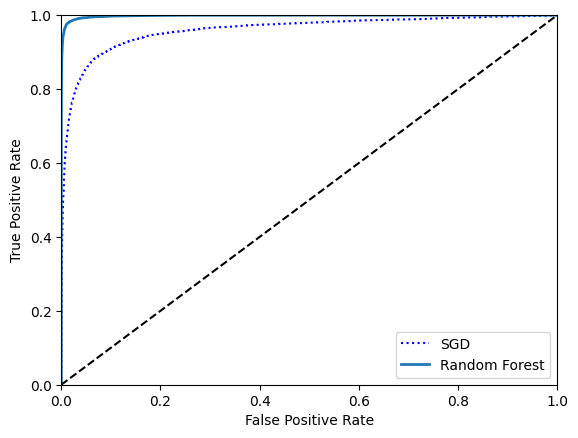

0.9899413243922883
0.8714259361741377


In [49]:
# Cross-validation ilə proba almaq

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

forest_clf = RandomForestClassifier(random_state=42)

y_probas_forest = cross_val_predict(
                                    forest_clf,
                                    X_train,
                                    y_train_5,
                                    cv=3,
                                    method="predict_proba"
                                    )
# ROC curve üçün score lazım olduğundan, positive class probability istifadə edirik:
y_scores_forest = y_probas_forest[:, 1]  # 1-ci sütun = positive class

#ROC curve üçün FPR və TPR hesablayırıq
from sklearn.metrics import roc_curve
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

# ROC curve müqayisəsi
import matplotlib.pyplot as plt
plt.plot(fpr, tpr, "b:", label="SGD")  # əvvəlki SGD curve
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_train_5, y_scores_forest))


# Precision və Recall 
# Random Forest-un positive class threshold-u default 0.5 olduqda
from sklearn.metrics import precision_score, recall_score
y_train_pred_forest = (y_scores_forest > 0.5)
print(precision_score(y_train_5, y_train_pred_forest))
print(recall_score(y_train_5, y_train_pred_forest))




# Multiclass Classification (Çoxsinifli Təsnifat)

2-dən çox sinifi ayırd edə bilir

1) Multiclass üçün yanaşmalar

a) Algoritmlərin doğrudan çoxsinifli dəstəyi
Məsələn: Random Forest, Naive Bayes

Bunlar birdən çox sinifi birbaşa idarə edə bilir → model avtomatik hər sinif üçün qərar verir

b) Binary classifier-lardan istifadə (OvA və OvO)

Binary classifier-lar yalnız iki sinif ayıra bilir, amma onları kombinə etməklə multiclass təsnifat mümkündür.

i) One-versus-all (OvA) / One-versus-rest

her sinfe bir binary classifier qrulur ,meseln 10 eded varsa 10 detector var .
Yeni  numune tesnifatinda her classifier ucun  decision score alinir ve en yuksk olani secilir .

ii) One-versus-one (OvO)

n sniof ucun  n *  (n-1)/ 2 klassifier qurulur

Ekser hallrda binary klassier multi class-la oyredilende OvA tetbiq edilir , amma svm  de oVo tetbiq olunur>

In [ ]:
sgd_clf.fit(X_train, y_train)  # y_train = 0–9 rəqmləri
sgd_clf.predict([some_digit])
# array([5])


array([5])

# SGDClassifier-də decision scores

In [ ]:
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores # 10 score, hər biri bir sinifə aid

array([[-11957.60099763, -28260.55780039, -13304.69392546,
         -1047.9950177 , -12859.0887725 ,   2888.61006651,
        -29458.35920229, -14568.79731484,  -9929.02878017,
         -7279.20131141]])

In [ ]:
np.argmax(some_digit_scores) # ən yüksək score-un sinif indeksini qaytarır → predicted class

np.int64(5)

In [ ]:
sgd_clf.classes_  # modelin yadda saxladığı target siniflər

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [57]:
sgd_clf.classes_[5]

np.int64(5)

In [ ]:
from sklearn.multiclass import OneVsOneClassifier

ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train, y_train)
ovo_clf.predict([some_digit])

len(ovo_clf.estimators_)

# OvO → hər sinif cütü üçün binary classifier qurur

# OvA → hər sinif üçün bütün digər siniflərə qarşı classifier qurur

45

In [ ]:
forest_clf.fit(X_train, y_train)
forest_clf.predict([some_digit])
# array([5.])

forest_clf.predict_proba([some_digit])
# array([[0., 0., 0., 0.06, 0., 0.93, 0., 0., 0.01, 0.]])

# Bu, modelin prediction confidence-ini göstərir

array([[0.  , 0.  , 0.  , 0.06, 0.  , 0.93, 0.  , 0.  , 0.01, 0.  ]])

In [ ]:
cross_val_score(sgd_clf,
                 X_train,
                   y_train,
                     cv=3,
                       scoring="accuracy")

# Accuracy ≈ 84–86%

array([0.84645, 0.8654 , 0.87345])

In [61]:
# Inputları standartlaşdırmaq (StandardScaler) modelin performansını artırır

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

cross_val_score(sgd_clf,
                 X_train_scaled,
                   y_train,
                     cv=3,
                       scoring="accuracy")

# Gradient descent linear model üçün daha stabil və sürətli öyrənmə

c:\Users\USER\envs\env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\USER\envs\env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\USER\envs\env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89785, 0.9006 , 0.89755])

+ Linear models → input scaling kritikdir

+ Random Forest → scaling tələb etmir, lakin memory və compute daha yüksək ola bilər

+ Cross-validation → hər zaman model performansını real qiymətləndirmək üçün vacibdir

# Error Analysis

Error analysis, yəni modelin səhv etdiyi nümunələri analiz etmək, ML layihəsinin ən kritik addımlarından biridir. Sadəcə accuracy-yə baxmaq kifayət etmir, çünki model bəzi siniflərdə daha çox səhv edə bilər.

# Confusion Matrix

In [62]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx      = confusion_matrix(y_train, y_train_pred)
conf_mx

c:\Users\USER\envs\env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\USER\envs\env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\USER\envs\env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5596,    0,   18,    5,    9,   32,   33,    6,  223,    1],
       [   2, 6405,   44,   18,    3,   43,    4,    7,  205,   11],
       [  26,   28, 5244,   90,   79,   18,   58,   38,  368,    9],
       [  28,   20,  116, 5203,    0,  199,   25,   44,  430,   66],
       [  10,   16,   42,   10, 5211,   11,   38,   16,  334,  154],
       [  29,   18,   32,  149,   51, 4437,   78,   15,  546,   66],
       [  32,   15,   46,    0,   38,   84, 5564,    4,  135,    0],
       [  22,    9,   53,   23,   47,   12,    3, 5691,  195,  210],
       [  16,   60,   38,   93,    2,  118,   30,    8, 5440,   46],
       [  23,   20,   25,   57,  129,   32,    1,  178,  355, 5129]])

Her dioqonal elemnti  duzgun tesnifat-dir, diaqonaldan kenar elematler is yanlisdir>

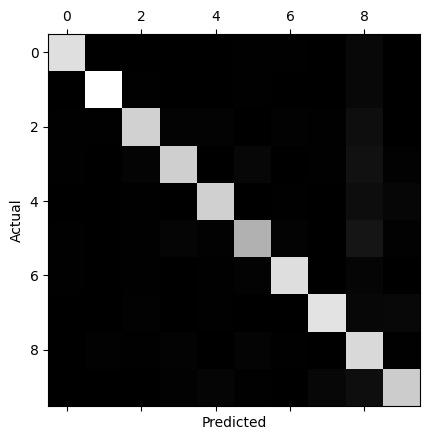

In [63]:
import matplotlib.pyplot as plt

plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Tünd rəng → daha çox səhv / daha çox nümunə

# Diagonal → doğru proqnozlar

# Off-diagonal → hansı siniflərin qarışdığını vizual göstərir

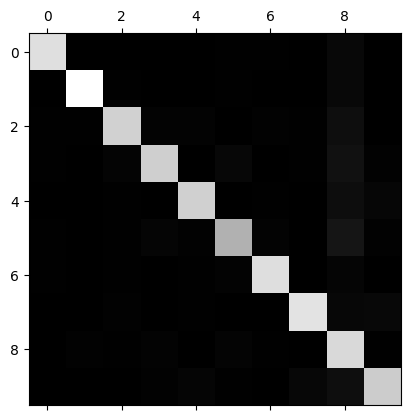

In [64]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

# reng nisbeten tund olarsa az numune var 

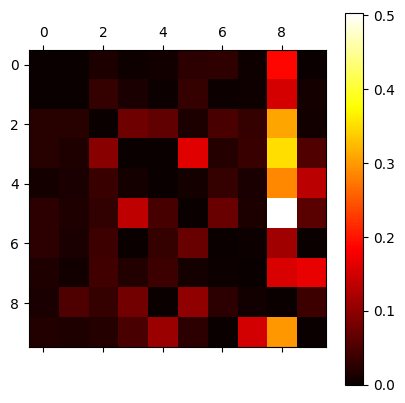

In [69]:
# Səhv nisbətlərini görmək üçün hər satırı (sinifi) onun ümumi sayına bölmək lazımdır:

row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx * 5, cmap=plt.cm.hot)
plt.colorbar()
plt.show()

# İndi heatmap yalnız səhvləri göstərir
# Daha tünd hüceyrələr → modelin səhv etdiyi sinif cütləri
# Məsələn: 3-lər 5-lərlə qarışırsa, 3-cü satır və 5-ci sütun tünd görünəcək

Əsas diqqət:

8 və 9-ların tanınmasını yaxşılaşdırmaq

3 və 5 qarışıqlığını azaltmaq

# Səhvləri necə azaltmaq olar?
1. Data səviyyəsində

8 və 9 üçün daha çox training nümunəsi toplamaq

Data augmentation:

+ fırlatma (rotation)

+ mərkəzləmə (centering)

+ miqyaslama (scaling)

2. Feature engineering

Struktur xüsusiyyətlər əlavə etmək:

“bağlı halqaların sayı”

+ 8 → 2 halqa

+ 6 → 1 halqa

+ 5 → 0 halqa

SGDclassifeir linear modeldir ,  her piksele ceki vurur ve cemleyir. mes: 3 ve 5 yalniz bir nece piksesl ferqlenir , firlansa , surusse sehv oxunur .


### Ən praktik həll

Şəkilləri əvvəlcədən emal etmək (preprocessing)

Xüsusilə:

Mərkəzləmə

Rotasiya düzəltməsi

Normalizasiya

# Multilabel Classification

Hər nümunə → birdən çox sinif


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# Burada hər rəqəm üçün iki etiket yaradılır: large ve odd
y_train_large = (y_train >= 7)   # 7,8,9 -dur ?
y_train_odd   = (y_train % 2 == 1)  # Tekdir ?
y_multilabel  = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier() 
# knn-tebii  olaraq multi output destekleyir
# Yəni hər label üçün ayrıca səsvermə edir
knn_clf.fit(X_train, y_multilabel)
knn_clf.predict([some_digit])      # large deyil , tekdir  = array([[False, True]])

y_train_knn_pred = cross_val_predict(knn_clf,
                                      X_train,
                                        y_multilabel,
                                          cv=3)

# Hər nümunənin bir neçə etiketi var ,Hər biri ayrıca səhv ola bilər.
# label-based metrics
f1_score(y_multilabel, y_train_knn_pred, average="macro")

# macro -   her label  ucun precision, recall, F1 hesablayır, sonra orta alir yeni bearber ehemiyyetli edir large ve odd -u 


# eger dataset-de odd cox , large azdirsa 
f1_score(y_multilabel, y_train_knn_pred, average="weighted") 
# Hər label-ın F1-ını , Onun support-u ilə çəkiləndirir.



0.977161141038085

# Multioutput Classification

Multiclass → 1 çıxış, çox sinif

Multilabel → çox çıxış, hər biri binary

Multioutput → çox çıxış, hər biri multiclass

+ Ses kuylu  MNIST  dataseti  giris kimi verilir , ve temiz sekilde output kimi cixmalidir. 
+ her piksel ayri  bir label-dir
+ her label 0-255 arasidir. 
+ bu  hem  multilabel  hem  de multiclass dir ve onda bu multioutput classification-dir.

+ Bu  eslinde riyazi baximdan Reqressiya problemdir , praktik cehetdende diskret multi-class .
+ Classification və regression arasında sərt xətt yoxdur; əsas olan problemin çıxış strukturudur.

### Niye knn?

her piksel ucun  yaxin qonsu  hesablayir ve orta tapir.yeni deyirki   
“Bu noisy şəkilə ən çox oxşayan təmiz şəkillər hansılardır? Onların orta piksel dəyərlərini götürüm.”

In [ ]:
# “Bu səs-küylü versiyanı gör, orijinalını qaytar.”
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise

noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise

y_train_mod = X_train
y_test_mod = X_test

# knn_clf.fit(X_train_mod, y_train_mod)
# clean_digit = knn_clf.predict([X_test_mod[some_index]])
# plot_digit(clean_digit)